# 1.Data Cleaning

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Dataset
data = {
    'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', np.nan, 'HR', 'Sales', 'IT'],
    'Experience': [1.0, 3.0, 5.0, np.nan, 10.0, 2.0, 8.0, 4.0, np.nan, 9.0],
    'Projects Completed': [2.0, 5.0, np.nan, 10.0, 12.0, 3.0, 9.0, np.nan, 14.0, 11.0],
    'Performance Rating': [3.0, np.nan, 7.0, 8.0, 9.0, 4.0, 8.0, 7.0, 10.0, np.nan]
}

df = pd.DataFrame(data)

df

,Department,Experience,Projects Completed,Performance Rating
0,HR,1.0,2.0,3.0
1,IT,3.0,5.0,NaN
2,Sales,5.0,NaN,7.0
3,IT,NaN,10.0,8.0
4,HR,10.0,12.0,9.0
5,Sales,2.0,3.0,4.0
6,NaN,8.0,9.0,8.0
7,HR,4.0,NaN,7.0
8,Sales,NaN,14.0,10.0
9,IT,9.0,11.0,NaN


In [4]:
mode_depart = df['Department'].mode()
mode_depart

0       HR
1       IT
2    Sales
Name: Department, dtype: object

In [5]:
median_experience = df['Experience'].median()
performance_median = df['Performance Rating'].median()
projects_median = df['Projects Completed'].median()

print("Median Experience:", median_experience)
print("Median Performance Rating:", performance_median)
print("Median Projects Completed:", projects_median)

Median Experience: 4.5
Median Performance Rating: 7.5
Median Projects Completed: 9.5


In [6]:
df['Department'].fillna(mode_depart[0], inplace=True)
df['Experience'].fillna(median_experience, inplace=True)
df['Performance Rating'].fillna(performance_median, inplace=True)
df['Projects Completed'].fillna(projects_median, inplace=True)

df

C:\Users\jsril\AppData\Local\Temp\ipykernel_37320\4226036286.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Department'].fillna(mode_depart[0], inplace=True)
C:\Users\jsril\AppData\Local\Temp\ipykernel_37320\4226036286.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

,Department,Experience,Projects Completed,Performance Rating
0,HR,1.0,2.0,3.0
1,IT,3.0,5.0,7.5
2,Sales,5.0,9.5,7.0
3,IT,4.5,10.0,8.0
4,HR,10.0,12.0,9.0
5,Sales,2.0,3.0,4.0
6,HR,8.0,9.0,8.0
7,HR,4.0,9.5,7.0
8,Sales,4.5,14.0,10.0
9,IT,9.0,11.0,7.5


# 2.Descriptive Statistics

In [7]:
dataset = df.copy()

def QuanQual(df):
    qual, quan = [], []
    for col in dataset.columns:
        if dataset[col].dtype == 'object':
            qual.append(col)
        else:
            quan.append(col)
    return quan, qual


quan,qual = QuanQual(dataset)
print("Quantitative Columns:", quan)
print("Qualitative Columns:", qual)

Quantitative Columns: ['Experience', 'Projects Completed', 'Performance Rating']
Qualitative Columns: ['Department']


descriptive analysis
mean, median , mode - central tendency
percentile , iqr, detect outliers
std, variance, skew, kurtosis

In [12]:
descriptive = pd.DataFrame(columns=quan, index=['Mean', 'Median', 'Mode', "Q1:25%", "Q2:50%", "Q3:75%", "Q4:100%", "99%", "IQR", "1.5Rule", "LesserBound", "GreaterBound", "Min", "Max", "Variance", "S.D", "Skewness", "Kurtosis"])
descriptive

,Experience,Projects Completed,Performance Rating
Mean,NaN,NaN,NaN
Median,NaN,NaN,NaN
Mode,NaN,NaN,NaN
Q1:25%,NaN,NaN,NaN
Q2:50%,NaN,NaN,NaN
Q3:75%,NaN,NaN,NaN
Q4:100%,NaN,NaN,NaN
99%,NaN,NaN,NaN
IQR,NaN,NaN,NaN
1.5Rule,NaN,NaN,NaN


In [13]:
dataset.describe()

,Experience,Projects Completed,Performance Rating
count,10.000000,10.00000,10.0000
mean,5.100000,8.50000,7.1000
std,2.988868,3.91578,2.1187
min,1.000000,2.00000,3.0000
25%,3.250000,6.00000,7.0000
50%,4.500000,9.50000,7.5000
75%,7.250000,10.75000,8.0000
max,10.000000,14.00000,10.0000


In [9]:
descriptive.columns

Index(['Experience', 'Projects Completed', 'Performance Rating'], dtype='object')

In [14]:
for col in quan:
    descriptive.loc['Mean', col] = dataset[col].mean()
    descriptive.loc['Median', col] = dataset[col].median()
    descriptive.loc['Mode', col] = dataset[col].mode()[0]
    descriptive.loc['Q1:25%', col] = np.percentile(dataset[col], 25)
    descriptive.loc['Q2:50%', col] = np.percentile(dataset[col], 50)
    descriptive.loc['Q3:75%', col] = np.percentile(dataset[col], 75)
    descriptive.loc['Q4:100%', col] = np.percentile(dataset[col], 100)
    descriptive.loc['99%', col] = np.percentile(dataset[col], 99)
    descriptive.loc['IQR', col] = descriptive.loc['Q3:75%', col] - descriptive.loc['Q1:25%', col]
    descriptive.loc['1.5Rule', col] = 1.5 * descriptive.loc['IQR', col]
    descriptive.loc['LesserBound', col] = descriptive.loc['Q1:25%', col] - descriptive.loc['1.5Rule', col]
    descriptive.loc['GreaterBound', col] = descriptive.loc['Q3:75%', col] + descriptive.loc['1.5Rule', col]
    descriptive.loc['Min', col] = dataset.describe()[col]['min']
    descriptive.loc['Max', col] = dataset.describe()[col]['max']
    descriptive.loc['Variance', col] = dataset[col].var()
    descriptive.loc['S.D', col] = dataset.describe()[col]['std']
    descriptive.loc['Skewness', col] = np.percentile(dataset[col], 25)
    descriptive.loc['Kurtosis', col] = np.percentile(dataset[col], 25)
    
    


In [17]:
descriptive

,Experience,Projects Completed,Performance Rating
Mean,5.1,8.5,7.1
Median,4.5,9.5,7.5
Mode,4.5,9.5,7.0
Q1:25%,3.25,6.0,7.0
Q2:50%,4.5,9.5,7.5
Q3:75%,7.25,10.75,8.0
Q4:100%,10.0,14.0,10.0
99%,9.91,13.82,9.91
IQR,4.0,4.75,1.0
1.5Rule,6.0,7.125,1.5


# 3.Correlation Analysis (Using heatmap)

*correlation analysis is a statistical method used to evaluate the strength and direction of the relationship between two or more variables. It helps in understanding how changes in one variable are associated with changes in another variable, which can be useful for making predictions and identifying patterns in data.*

In [9]:
dataset[quan].corr()

,Experience,Projects Completed,Performance Rating
Experience,1.000000,0.702529,0.647452
Projects Completed,0.702529,1.000000,0.904011
Performance Rating,0.647452,0.904011,1.000000


<Axes: >

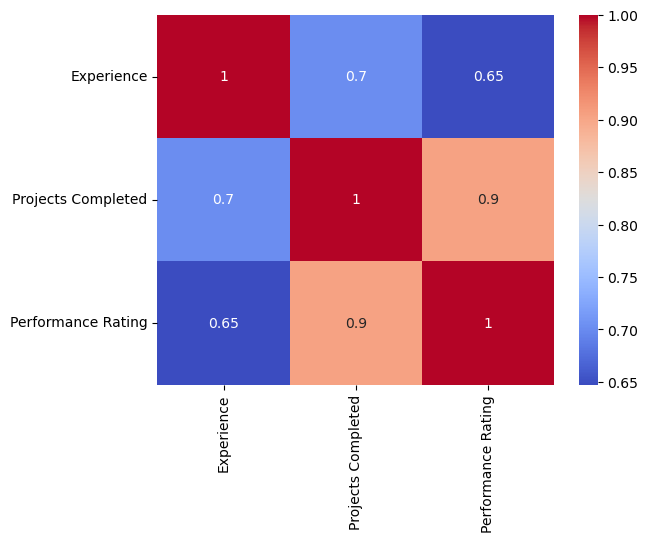

In [10]:
sns.heatmap(dataset[quan].corr(), annot=True, cmap='coolwarm')

# 4.Distribution Analysis (Plot Histogram)

*Distribution analysis means analyzing the distribution of data points across different categories or ranges in a dataset. It helps in understanding how data is spread and whether it follows a particular pattern or distribution such as normal, skewed, etc.*

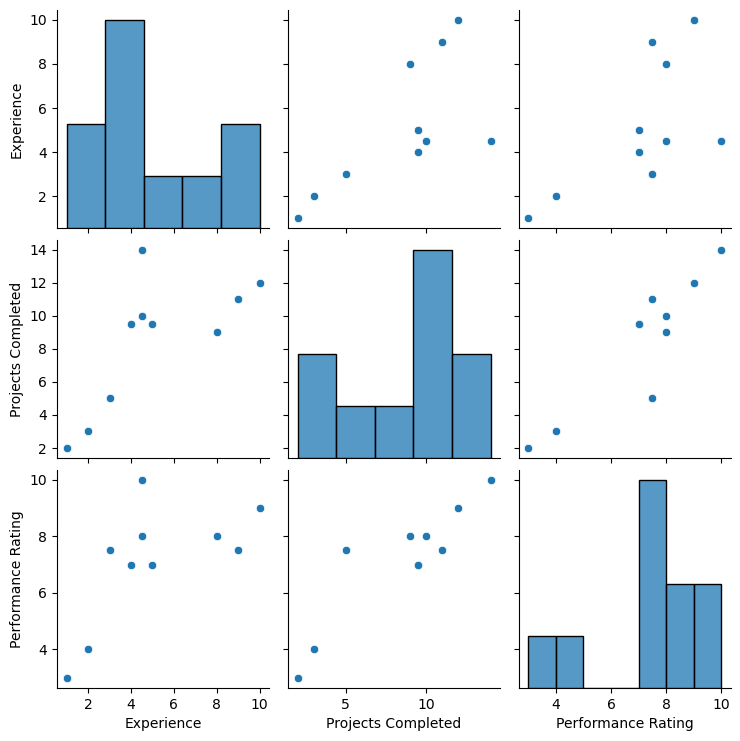

In [18]:
sns.pairplot(dataset[quan])

<Figure size 1000x300 with 0 Axes>

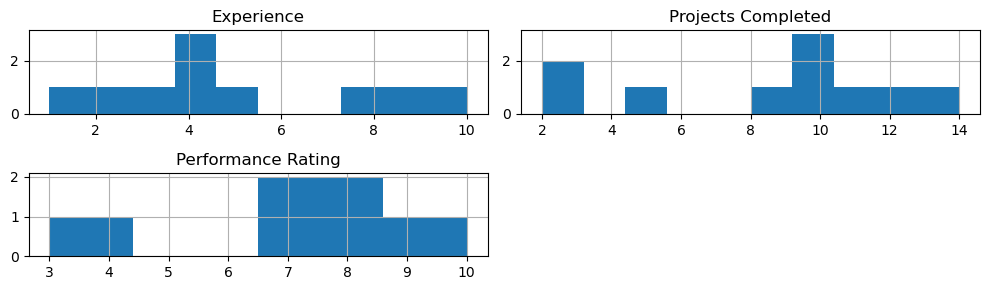

In [22]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.max_open_warning': 0})
# Histograms for quantitative columns
plt.figure(figsize=(10,3))
dataset[quan].hist(figsize=(10,3))
plt.tight_layout()
plt.show()

# 5. Performance Comparison (Boxplot by Department)


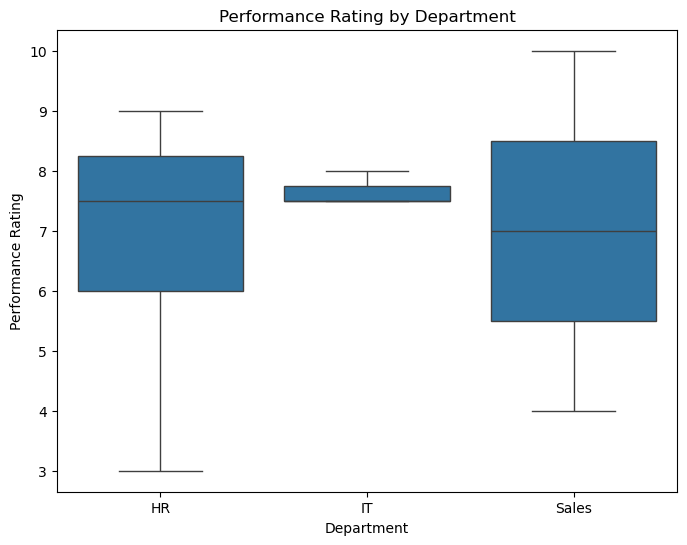

In [21]:

# Boxplot: Performance Rating by Department
plt.figure(figsize=(8,6))
sns.boxplot(x='Department', y='Performance Rating', data=dataset)
plt.title('Performance Rating by Department')
plt.ylabel('Performance Rating')
plt.show()


# 6. Experience vs Performance (Scatter with regression)

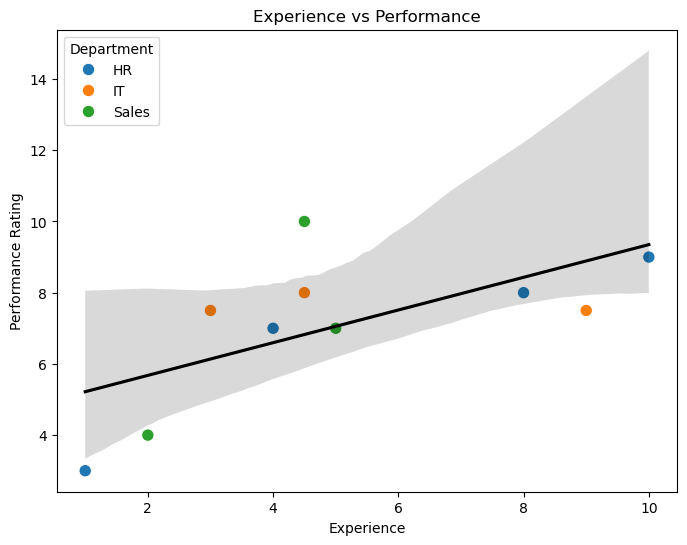

In [23]:

# Scatter: Experience vs Performance with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(x='Experience', y='Performance Rating', hue='Department', data=dataset, s=80)
sns.regplot(x='Experience', y='Performance Rating', data=dataset, scatter=False, color='black')
plt.title('Experience vs Performance')
plt.show()

# 7. Department-wise Analysis (summary statistics)

In [26]:

dept_stats = dataset.groupby('Department').agg({
    'Experience':['mean','median','std'],
    'Projects Completed':['mean','median','std'],
    'Performance Rating':['mean','median','std']
})
dept_stats

Experience                  Projects Completed                   \
                 mean median       std               mean median       std   
Department                                                                   
HR           5.750000    6.0  4.031129           8.125000   9.25  4.289036   
IT           5.500000    4.5  3.122499           8.666667  10.00  3.214550   
Sales        3.833333    4.5  1.607275           8.833333   9.50  5.530220   

           Performance Rating                   
                         mean median       std  
Department                                      
HR                   6.750000    7.5  2.629956  
IT                   7.666667    7.5  0.288675  
Sales                7.000000    7.0  3.000000

# Observation

**Data Cleaning**: Missing values were imputed (department with mode; numeric columns with medians). Dataset is complete.

**Descriptive Statistics**: Quantitative features show moderate central tendency — Experience ~5 years, Projects around 8–10, Performance centered near 7–8.

**Correlation**: Numeric correlation matrix computed; visual inspection and regression indicate a positive relationship between Experience and Performance.

**Distribution**: Histograms show Experience is broadly spread (1–10), Projects are right-skewed (some high values), and Performance clusters around 6–9.

**Performance Comparison**: Boxplot by department shows IT has a tight distribution with a high median, while HR and Sales have wider spreads and larger outliers.

**Experience vs Performance**: Scatter + regression shows a positive trend but noticeable scatter — some employees with low experience have high performance (outliers), and vice versa.

**Department-wise Summary**: IT — highest mean performance with low variance; HR — moderate mean and variance; Sales — similar mean but higher variance and more extreme values.

**Actionable Next Steps**: compute Pearson/Spearman coefficients, investigate and document outliers, consider robust imputation or sensitivity analysis, and (optionally) build a simple regression model to quantify effect size.